In [5]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import glob

In [6]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [240]:
# check if all elements in array are larger than x
a = force_left[ic_left[0]:ic_left[0]+5]
min(a) == a[0]

True

In [243]:
def ic (force, fs):
    rfd = np.diff(force, n=1)*fs   # unit N/s
    rfd_1500 = list(np.where(rfd > 1500)[0])
    ic_true=[]
    for IC in rfd_1500:
        if ((force[IC+fs//20]) > (force[IC]+1000)) & (min(force[IC:IC+fs//20]) == force[IC:IC+fs//20][0]):
            if len(ic_true) == 0:
                ic_true.append(IC)
            elif IC > ic_true[-1]+fs//4:
                ic_true.append(IC)
    return ic_true

In [82]:
# stage 0: filter all pressure readings < 1 to 0
def offset_stage0(array3):
    array3[array3<1]=0
    return array3

In [258]:
df = pd.read_csv('D:\\Salzburg\\Study1\\P01\\P01_PI_df\\UB_level_9.csv')
left, right = separate_sides(df)
left = offset_stage0(left)
right = offset_stage0(right)
force_left = pi_force(left)
force_right = pi_force(right)

In [259]:
ic_left = np.array(ic(force_left, 100))
ic_right = np.array(ic(force_right, 100))

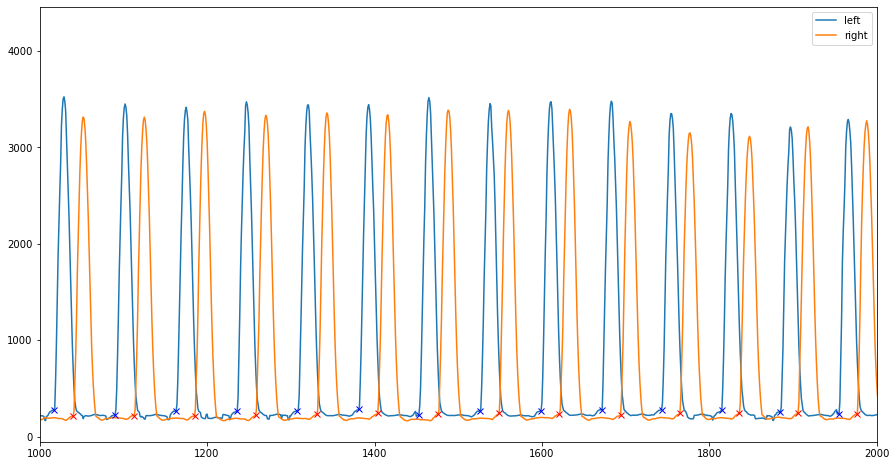

In [260]:
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.plot(ic_right, force_right[ic_right], 'rx')
plt.plot(ic_left, force_left[ic_left], 'bx')
plt.xlim(1000,2000)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [246]:
l = np.empty(left.shape)

In [254]:
def find_max_offset(array3, fs):
    offset = array3[:, :, -fs//4]
    for frame in range(-fs//4,-1):
        if np.sum(offset)<np.sum(array3[:,:,frame]):
            offset = array3[:,:,frame]
    return offset

In [255]:
def offset_stage1(array3, fs):
    offset = find_max_offset(array3, fs)
    for frame in range(array3.shape[2]):
        array3[:,:,frame]-=offset
    array3[array3<0]=0
    return array3

In [256]:
for i in range(len(ic_left)):
    if i == 0:
        l[:,:,:ic_left[i]] = offset_stage1(left[:,:,:ic_left[i]], 100)
    else:
        l[:,:,ic_left[i-1]:ic_left[i]] = offset_stage1(left[:,:,ic_left[i-1]:ic_left[i]], 100)

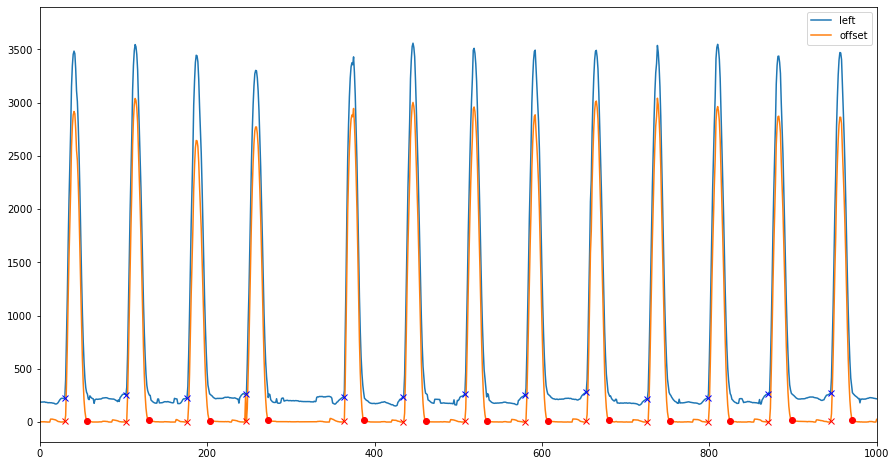

In [257]:
force_l = pi_force(l)
plt.plot(force_left[:], label='left')
plt.plot(force_l[:], label='offset')
plt.plot(ic_left, force_l[ic_left], 'rx')
plt.plot(to_left, force_l[to_left], 'ro')
plt.plot(ic_left, force_left[ic_left], 'bx')
plt.xlim(0,1000)
#plt.ylim(0,500)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [225]:
def pi_to(force_side, IC_side, fs):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time 0.1 s after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        pot_to = np.argwhere(force_side[IC+fs//10:] == 0)[0] + IC+fs//10
        TO_side.extend(pot_to)
    return TO_side

In [251]:
to_left = np.array(pi_to(force_l, ic_left,100))
np.diff(to_left, n=1)

array([ 74,  74,  69, 114,  74,  73,  73,  73,  73,  72,  74,  72,  73,
        73,  73,  72,  74,  74,  70,  74,  72,  73,  72,  72,  69,  69,
        72,  74,  73,  70,  72,  73,  74,  73,  72,  73,  73,  72,  73,
        74,  72,  72,  73,  72,  71,  75,  71,  74,  70,  74,  72,  73,
        73,  73,  73,  71,  73,  73,  73,  73,  72,  72,  73,  72,  74,
        71,  73,  74,  73,  73,  72,  72,  73,  74,  72,  73,  72,  73,
        73,  72], dtype=int64)

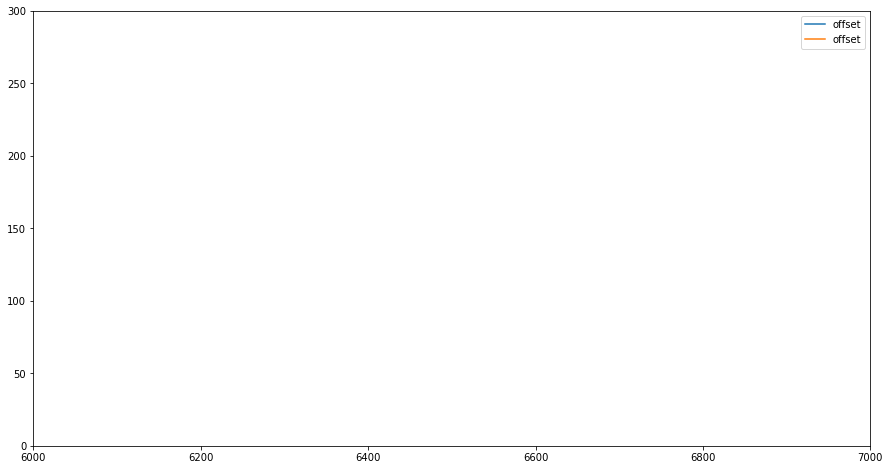

In [212]:
w1+=1000
w2=w1+1000
l[l<2]=0
force_l2 = pi_force(l)
#plt.plot(force_left[:], label='left')
plt.plot(force_l[:], label='offset')
plt.plot(force_l2[:], label='offset')
plt.plot(ic_left, force_l[ic_left], 'rx')
plt.plot(ic_left, force_l2[ic_left], 'rx')
#plt.plot(ic_left, force_left[ic_left], 'bx')
plt.xlim(w1,w2)
plt.ylim(0,300)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [261]:
pd.DataFrame(left[:,:,0])

,0,1,2,3,4,5,6,7,8,9,10
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,1.57,0.00,1.34,1.87,0.00,0.00
2,0.00,0.00,0.00,1.45,0.00,1.12,1.26,2.34,2.43,1.92,0.00
3,0.00,0.00,1.49,0.00,0.00,0.00,0.00,1.67,3.38,4.45,0.00
4,0.00,0.00,1.34,0.00,0.00,0.00,0.00,0.00,3.52,4.66,0.00
5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.27,2.27,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,1.03,1.26,1.12,1.57,1.30,1.53,1.66,0.00,0.00
8,0.00,1.74,1.90,1.58,1.36,1.96,1.79,2.11,2.66,2.73,1.89
9,1.93,2.51,2.29,1.39,1.21,1.29,1.55,2.31,3.91,5.36,2.82
